# Visualización de datos raw

Muestra los TAC completos y máscaras generados por `process_all_masks.py` (antes de preprocesar).
Los valores del CT están en unidades Hounsfield (HU) originales.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [19]:
# Cargar metadata
output_dir = "output"
meta = pd.read_csv(os.path.join(output_dir, "metadata.csv"))
meta = meta.drop_duplicates(subset=["patient_id", "nodule_idx"]).reset_index(drop=True)

print(f"Total nódulos: {len(meta)}")
print(f"Pacientes: {meta.patient_id.nunique()}")
meta.head(10)

Total nódulos: 432
Pacientes: 138


,patient_id,nodule_idx,num_annotations,vol_shape,bbox_x,bbox_y,bbox_z,subtlety,internalStructure,calcification,sphericity,margin,lobulation,spiculation,texture,malignancy
0,LIDC-IDRI-0078,0,4,"(512, 512, 87)",294-328,306-350,23-29,4.50,1.0,6.00,4.00,3.25,2.25,2.25,4.75,3.75
1,LIDC-IDRI-0078,1,4,"(512, 512, 87)",146-186,349-376,44-50,4.75,1.0,6.00,4.00,2.75,3.00,2.25,4.50,3.75
2,LIDC-IDRI-0078,2,1,"(512, 512, 87)",345-353,333-340,47-49,4.00,1.0,5.00,5.00,5.00,1.00,1.00,5.00,1.00
3,LIDC-IDRI-0078,3,4,"(512, 512, 87)",221-271,324-364,64-72,5.00,1.0,5.00,3.75,3.25,3.25,2.75,4.75,4.25
4,LIDC-IDRI-0069,0,4,"(512, 512, 136)",359-385,158-177,36-45,2.50,1.0,6.00,4.50,4.25,4.00,4.00,4.75,3.25
5,LIDC-IDRI-0069,1,1,"(512, 512, 136)",337-343,223-230,52-53,2.00,1.0,6.00,4.00,4.00,5.00,5.00,5.00,2.00
6,LIDC-IDRI-0069,2,4,"(512, 512, 136)",359-388,96-139,79-90,4.75,1.0,6.00,3.75,3.50,4.25,3.50,4.75,3.50
7,LIDC-IDRI-0079,0,4,"(512, 512, 113)",372-399,350-372,67-72,4.50,1.0,5.75,3.75,3.75,2.25,1.50,4.75,2.50
8,LIDC-IDRI-0101,0,2,"(512, 512, 150)",301-322,45-53,69-71,3.50,1.0,6.00,2.50,3.00,1.00,1.00,4.50,2.00
9,LIDC-IDRI-0110,0,3,"(512, 512, 125)",360-377,189-206,44-48,4.00,1.0,6.00,4.67,2.33,2.67,2.00,3.33,3.33


## 1. Distribución de malignancy

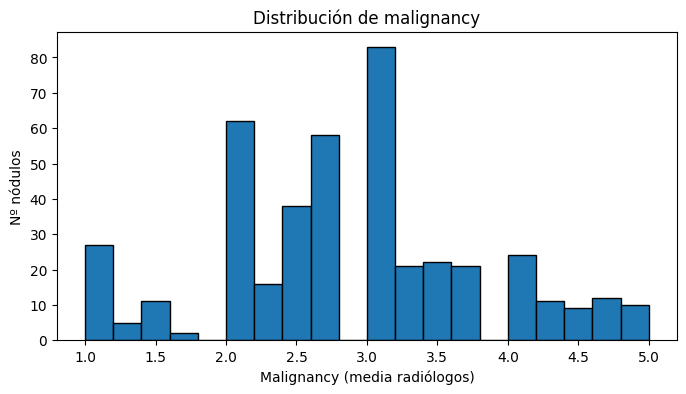

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(meta["malignancy"], bins=20, edgecolor="black")
plt.xlabel("Malignancy (media radiólogos)")
plt.ylabel("Nº nódulos")
plt.title("Distribución de malignancy")
plt.show()

## 2. Cargar un paciente

In [21]:
patient_id = meta.patient_id.unique()[0]  # <-- cambia el índice o pon un ID

ct = np.load(os.path.join(output_dir, "CT", f"{patient_id}.npy"))
mask = np.load(os.path.join(output_dir, "masks", f"{patient_id}.npy"))

patient_meta = meta[meta.patient_id == patient_id]

print(f"Paciente: {patient_id}")
print(f"Shape CT: {ct.shape}")
print(f"Rango HU: [{ct.min():.0f}, {ct.max():.0f}]")
print(f"Nódulos: {len(patient_meta)}")
print(f"Vóxeles con nódulo: {mask.sum()} de {mask.size} ({100*mask.sum()/mask.size:.4f}%)")

for _, row in patient_meta.iterrows():
    print(f"  nod{int(row.nodule_idx)}: bbox=({row.bbox_x}, {row.bbox_y}, {row.bbox_z}), mal={row.malignancy}")

Paciente: LIDC-IDRI-0078
Shape CT: (512, 512, 87)
Rango HU: [-2048, 8155]
Nódulos: 4
Vóxeles con nódulo: 7324 de 22806528 (0.0321%)
  nod0: bbox=(294-328, 306-350, 23-29), mal=3.75
  nod1: bbox=(146-186, 349-376, 44-50), mal=3.75
  nod2: bbox=(345-353, 333-340, 47-49), mal=1.0
  nod3: bbox=(221-271, 324-364, 64-72), mal=4.25


## 3. Slice central del TAC completo

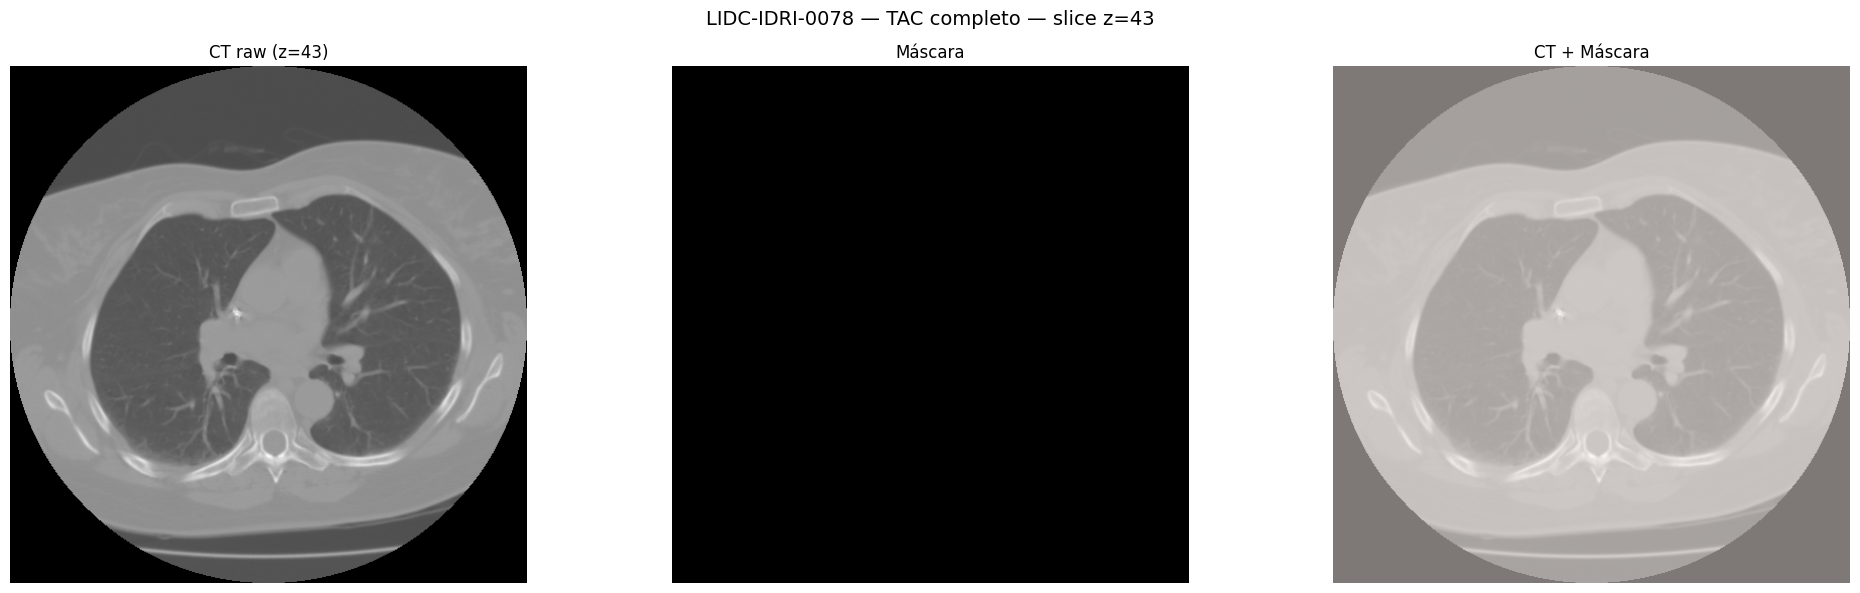

In [22]:
z = ct.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(ct[:, :, z], cmap="gray")
axes[0].set_title(f"CT raw (z={z})")
axes[0].axis("off")

axes[1].imshow(mask[:, :, z], cmap="gray")
axes[1].set_title("Máscara")
axes[1].axis("off")

axes[2].imshow(ct[:, :, z], cmap="gray")
axes[2].imshow(mask[:, :, z], alpha=0.5, cmap="Reds")
axes[2].set_title("CT + Máscara")
axes[2].axis("off")

plt.suptitle(f"{patient_id} — TAC completo — slice z={z}", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Slices con nódulo

Slices con nódulo: 20 de 87


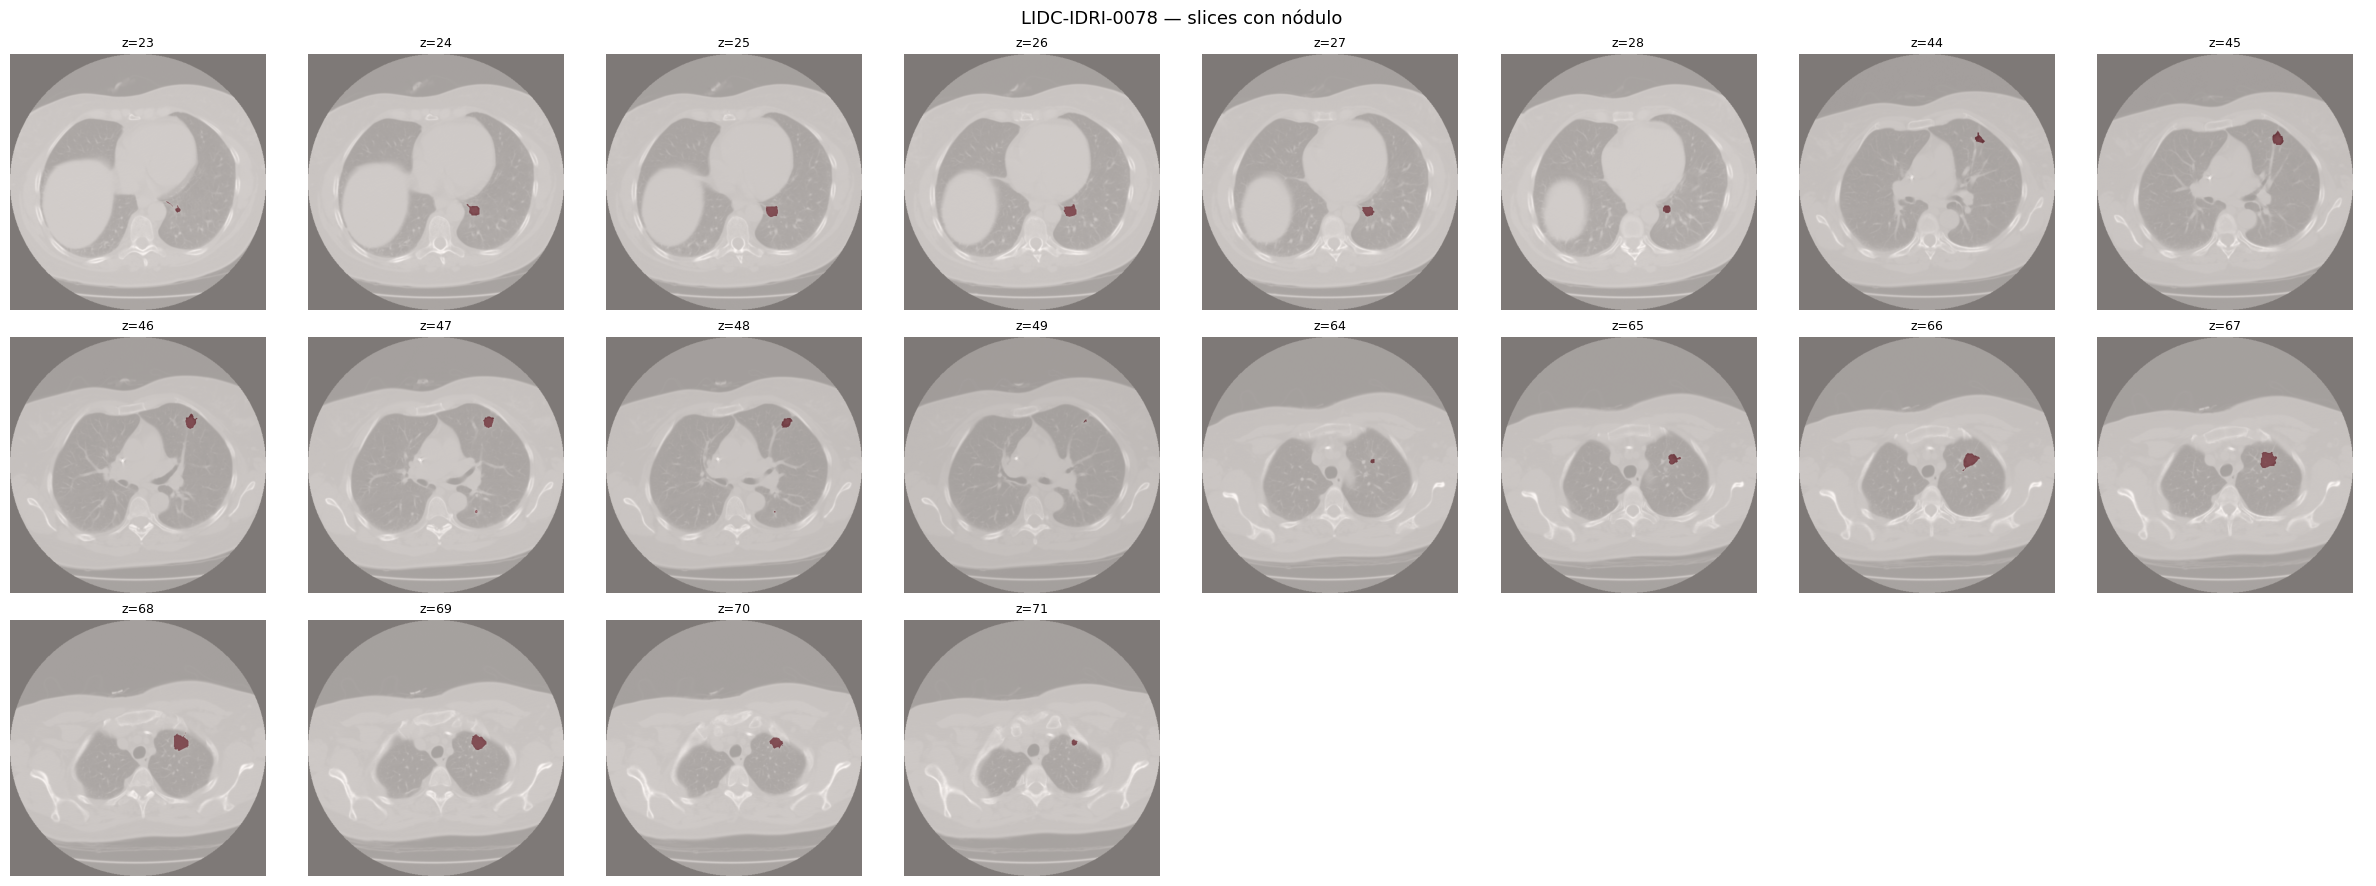

In [23]:
slices_with_nodule = [z for z in range(ct.shape[2]) if mask[:, :, z].sum() > 0]
print(f"Slices con nódulo: {len(slices_with_nodule)} de {ct.shape[2]}")

cols = min(len(slices_with_nodule), 8)
rows_grid = (len(slices_with_nodule) + cols - 1) // cols

fig, axes = plt.subplots(rows_grid, cols, figsize=(3 * cols, 3 * rows_grid))
axes = np.atleast_2d(axes)

for idx in range(rows_grid * cols):
    r, c = divmod(idx, cols)
    ax = axes[r, c]
    if idx < len(slices_with_nodule):
        z = slices_with_nodule[idx]
        ax.imshow(ct[:, :, z], cmap="gray")
        ax.imshow(mask[:, :, z], alpha=0.5, cmap="Reds")
        ax.set_title(f"z={z}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"{patient_id} — slices con nódulo", fontsize=13)
plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

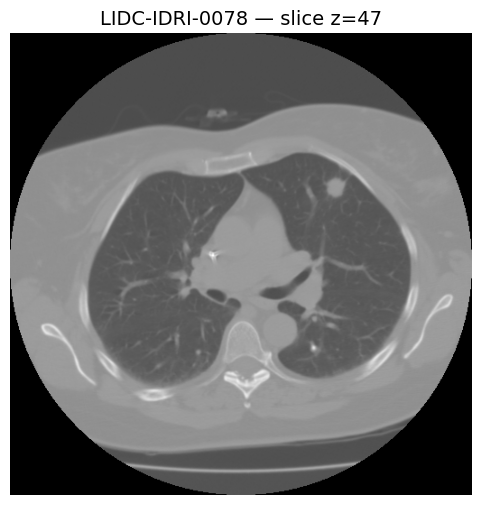

In [ ]:
# Mostrar solo la slice 49
z = 47
plt.figure(figsize=(6, 6))
plt.imshow(ct[:, :, z], cmap="gray")
plt.imshow(mask[:, :, z], alpha=0.5, cmap="Reds")
plt.title(f"{patient_id} — slice z={z}", fontsize=14)
plt.axis("off")

## 5. Zoom en cada nódulo

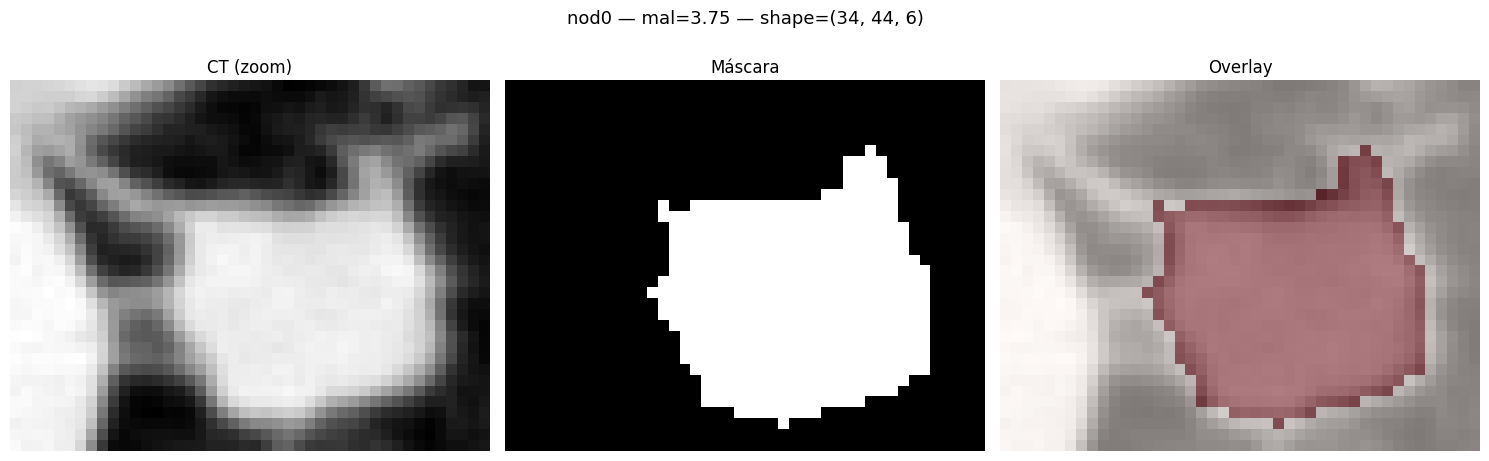

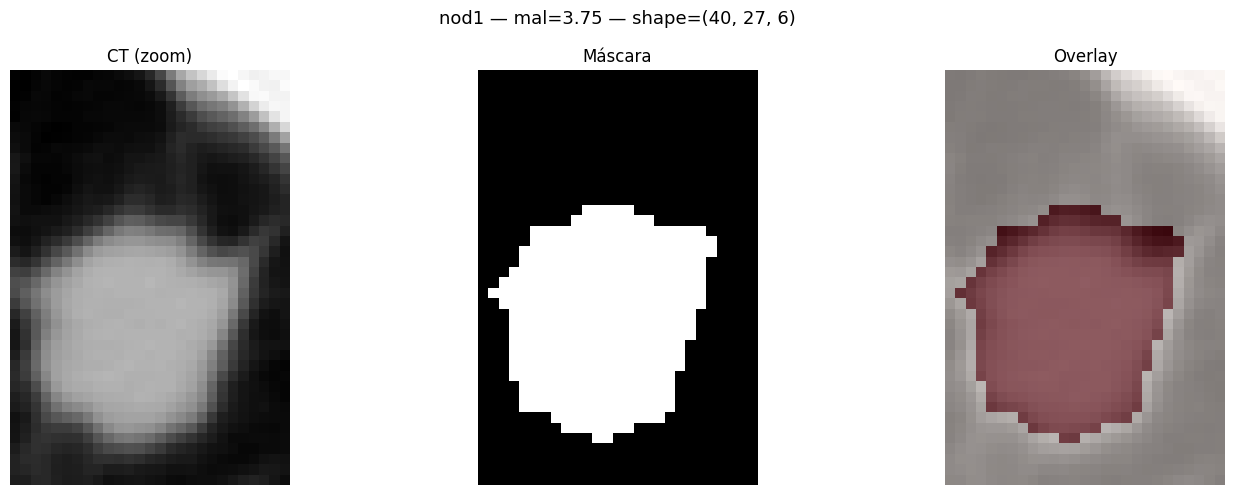

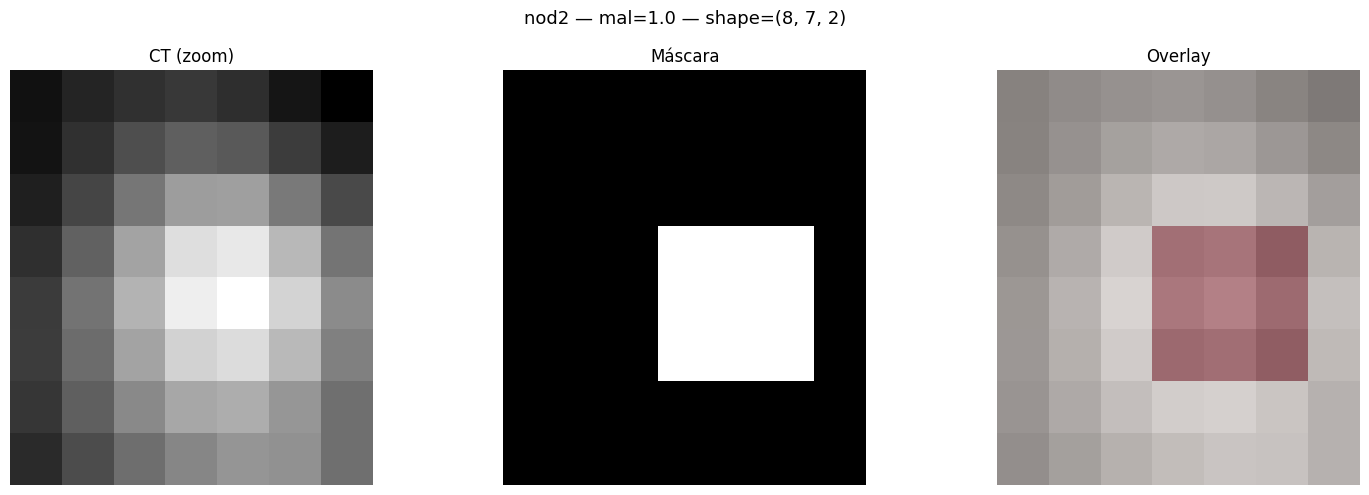

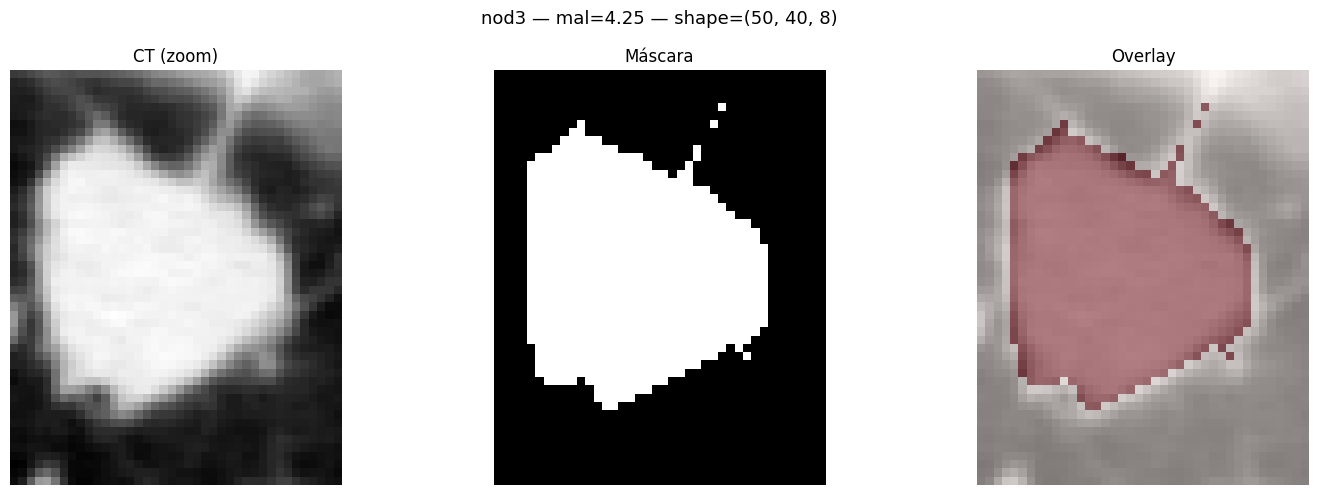

In [24]:
for _, row in patient_meta.iterrows():
    bx = [int(x) for x in row.bbox_x.split("-")]
    by = [int(x) for x in row.bbox_y.split("-")]
    bz = [int(x) for x in row.bbox_z.split("-")]
    
    ct_crop = ct[bx[0]:bx[1], by[0]:by[1], bz[0]:bz[1]]
    mask_crop = mask[bx[0]:bx[1], by[0]:by[1], bz[0]:bz[1]]
    z_mid = ct_crop.shape[2] // 2
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(ct_crop[:, :, z_mid], cmap="gray")
    axes[0].set_title("CT (zoom)")
    axes[0].axis("off")
    
    axes[1].imshow(mask_crop[:, :, z_mid], cmap="gray")
    axes[1].set_title("Máscara")
    axes[1].axis("off")
    
    axes[2].imshow(ct_crop[:, :, z_mid], cmap="gray")
    axes[2].imshow(mask_crop[:, :, z_mid], alpha=0.5, cmap="Reds")
    axes[2].set_title("Overlay")
    axes[2].axis("off")
    
    plt.suptitle(f"nod{int(row.nodule_idx)} — mal={row.malignancy} — shape={ct_crop.shape}", fontsize=13)
    plt.tight_layout()
    plt.show()

## 6. Recorrido por el TAC completo

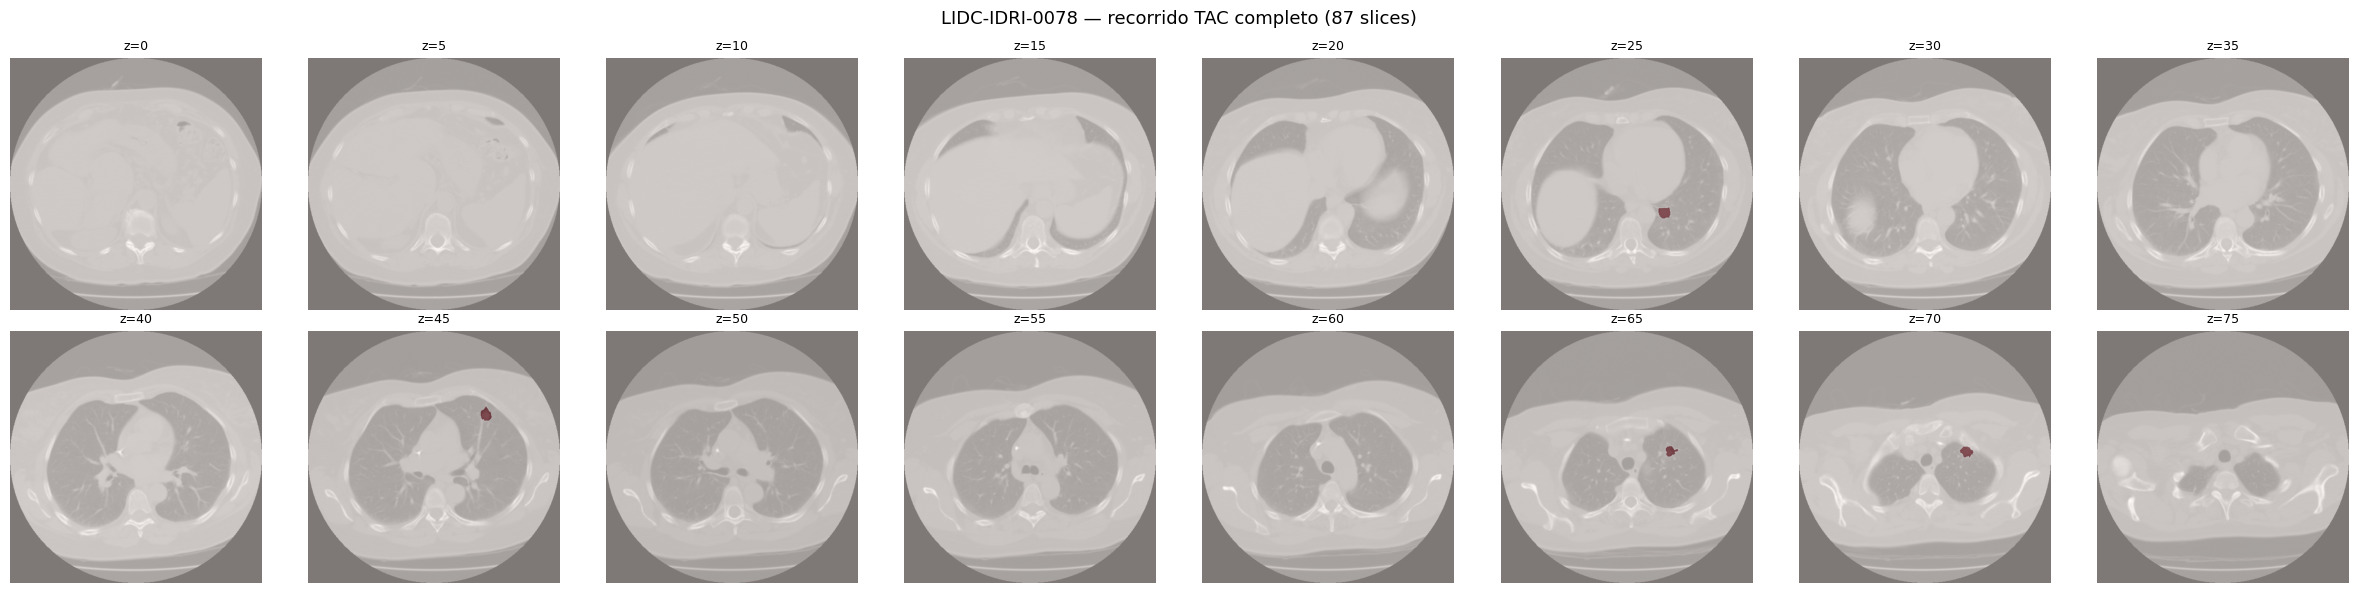

In [25]:
n_show = 16
step = max(ct.shape[2] // n_show, 1)
slices = list(range(0, ct.shape[2], step))[:n_show]

cols = min(n_show, 8)
rows_grid = (len(slices) + cols - 1) // cols

fig, axes = plt.subplots(rows_grid, cols, figsize=(3 * cols, 3 * rows_grid))
axes = np.atleast_2d(axes)

for idx in range(rows_grid * cols):
    r, c = divmod(idx, cols)
    ax = axes[r, c]
    if idx < len(slices):
        z = slices[idx]
        ax.imshow(ct[:, :, z], cmap="gray")
        ax.imshow(mask[:, :, z], alpha=0.5, cmap="Reds")
        ax.set_title(f"z={z}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"{patient_id} — recorrido TAC completo ({ct.shape[2]} slices)", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Resumen de features

In [26]:
features = ["subtlety", "sphericity", "margin", "lobulation", "spiculation", "texture", "malignancy"]
available = [f for f in features if f in meta.columns]
meta[available].describe().round(2)

,subtlety,sphericity,margin,lobulation,spiculation,texture,malignancy
count,432.00,432.00,432.00,432.00,432.00,432.00,432.00
mean,3.53,3.89,3.86,1.69,1.63,4.39,2.85
std,1.12,0.75,1.03,0.86,0.95,1.06,0.94
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,3.00,3.50,3.25,1.00,1.00,4.33,2.25
50%,3.75,4.00,4.00,1.33,1.25,5.00,2.75
75%,4.33,4.50,4.75,2.00,2.00,5.00,3.50
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00
